In [1]:
#import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
%matplotlib inline

### Loading Dataset

We use pandas to read the dataset and preprocess it

In [2]:
df = pd.read_csv("C:/Users/Admin/OneDrive/Desktop/Sharwari_All/Study Stuff/4th Sem Project/Customer Churn.csv")
df.shape

(7043, 21)

### Exploratory Data Analysis

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.size

147903

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

0

### Basic Data Cleaning

As we have already observed in above cell that TotalCharges is given as object but is float datatype. we will fix it here

In [11]:
df['TotalCharges'].dtype

dtype('O')

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df['TotalCharges'].dtype

dtype('float64')

In [14]:
categorical_features = [
    'gender', 
    'SeniorCitizen', 
    'Partner', 
    'Dependents',
    'PhoneService', 
    'MultipleLines', 
    'InternetService',
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport',
    'StreamingTV', 
    'StreamingMovies', 
    'Contract', 
    'PaperlessBilling',
    'PaymentMethod',
]
numerical_features = ['tenure','MonthlyCharges','TotalCharges']
target = 'Churn'

In [15]:
df.skew(numeric_only=True)

SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64

In [16]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


### Feature Distribution

We plot distribution for numerial and categorical features to check for outliers and compare feature distributions with target variable.

#### Numerical Features Distribution

Numeric summarizing techniques (mean, standard deviation, etc) don't show us spikes, shapes of distributions and its hard to observe outliers with it. that is the reason we use histrograms

In [17]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


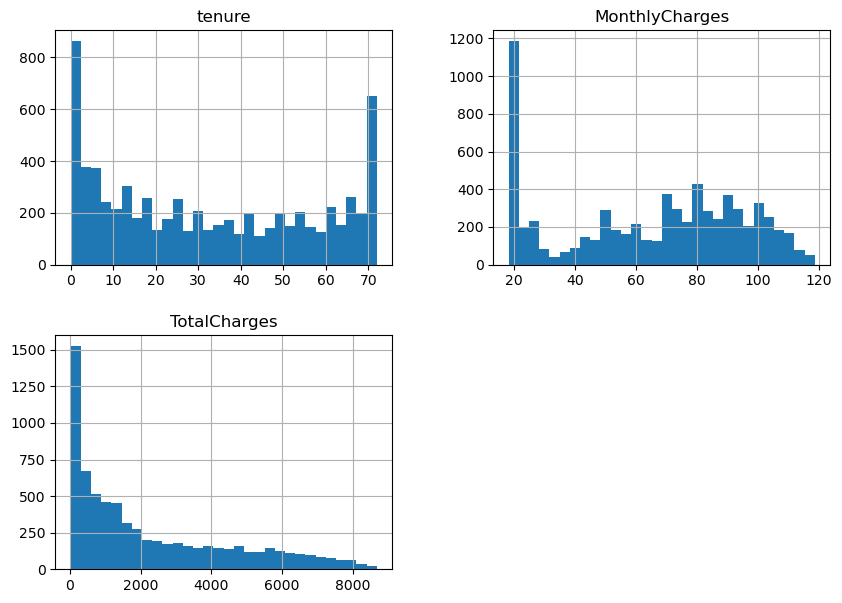

In [18]:
df[numerical_features].hist(bins=30, figsize=(10,7))
plt.show()

We look at distributions of numerical features in relation to the target variable. We can observe that the greater TotalCharges and tenure are the less is the probability of churn.

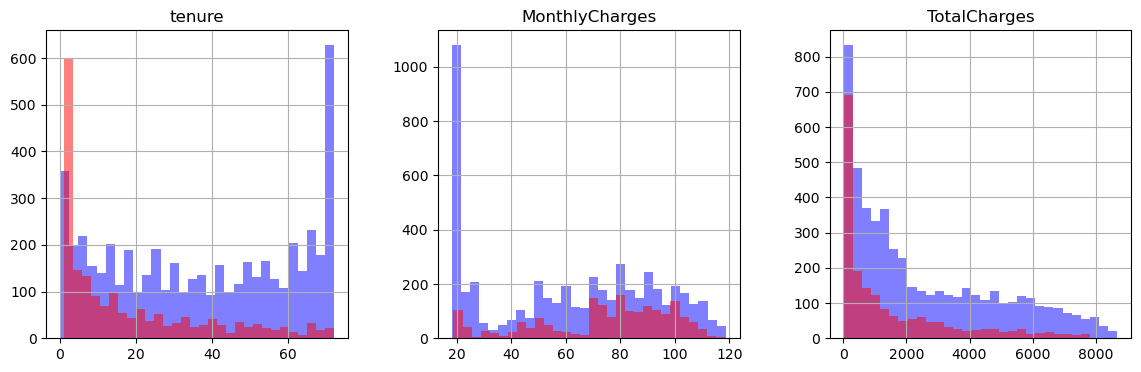

In [19]:
fig, ax = plt.subplots(1, 3, figsize = (14,4))
df[df.Churn == "No"][numerical_features].hist(bins=30, color='blue',alpha=0.5,ax=ax)
df[df.Churn == "Yes"][numerical_features].hist(bins=30, color='red',alpha=0.5,ax=ax)
plt.show()

### Categorical Feature Distribution

To analyze categorical features we use bar charts. We observe that senior Citizens and customers without phone service are less represented in the data

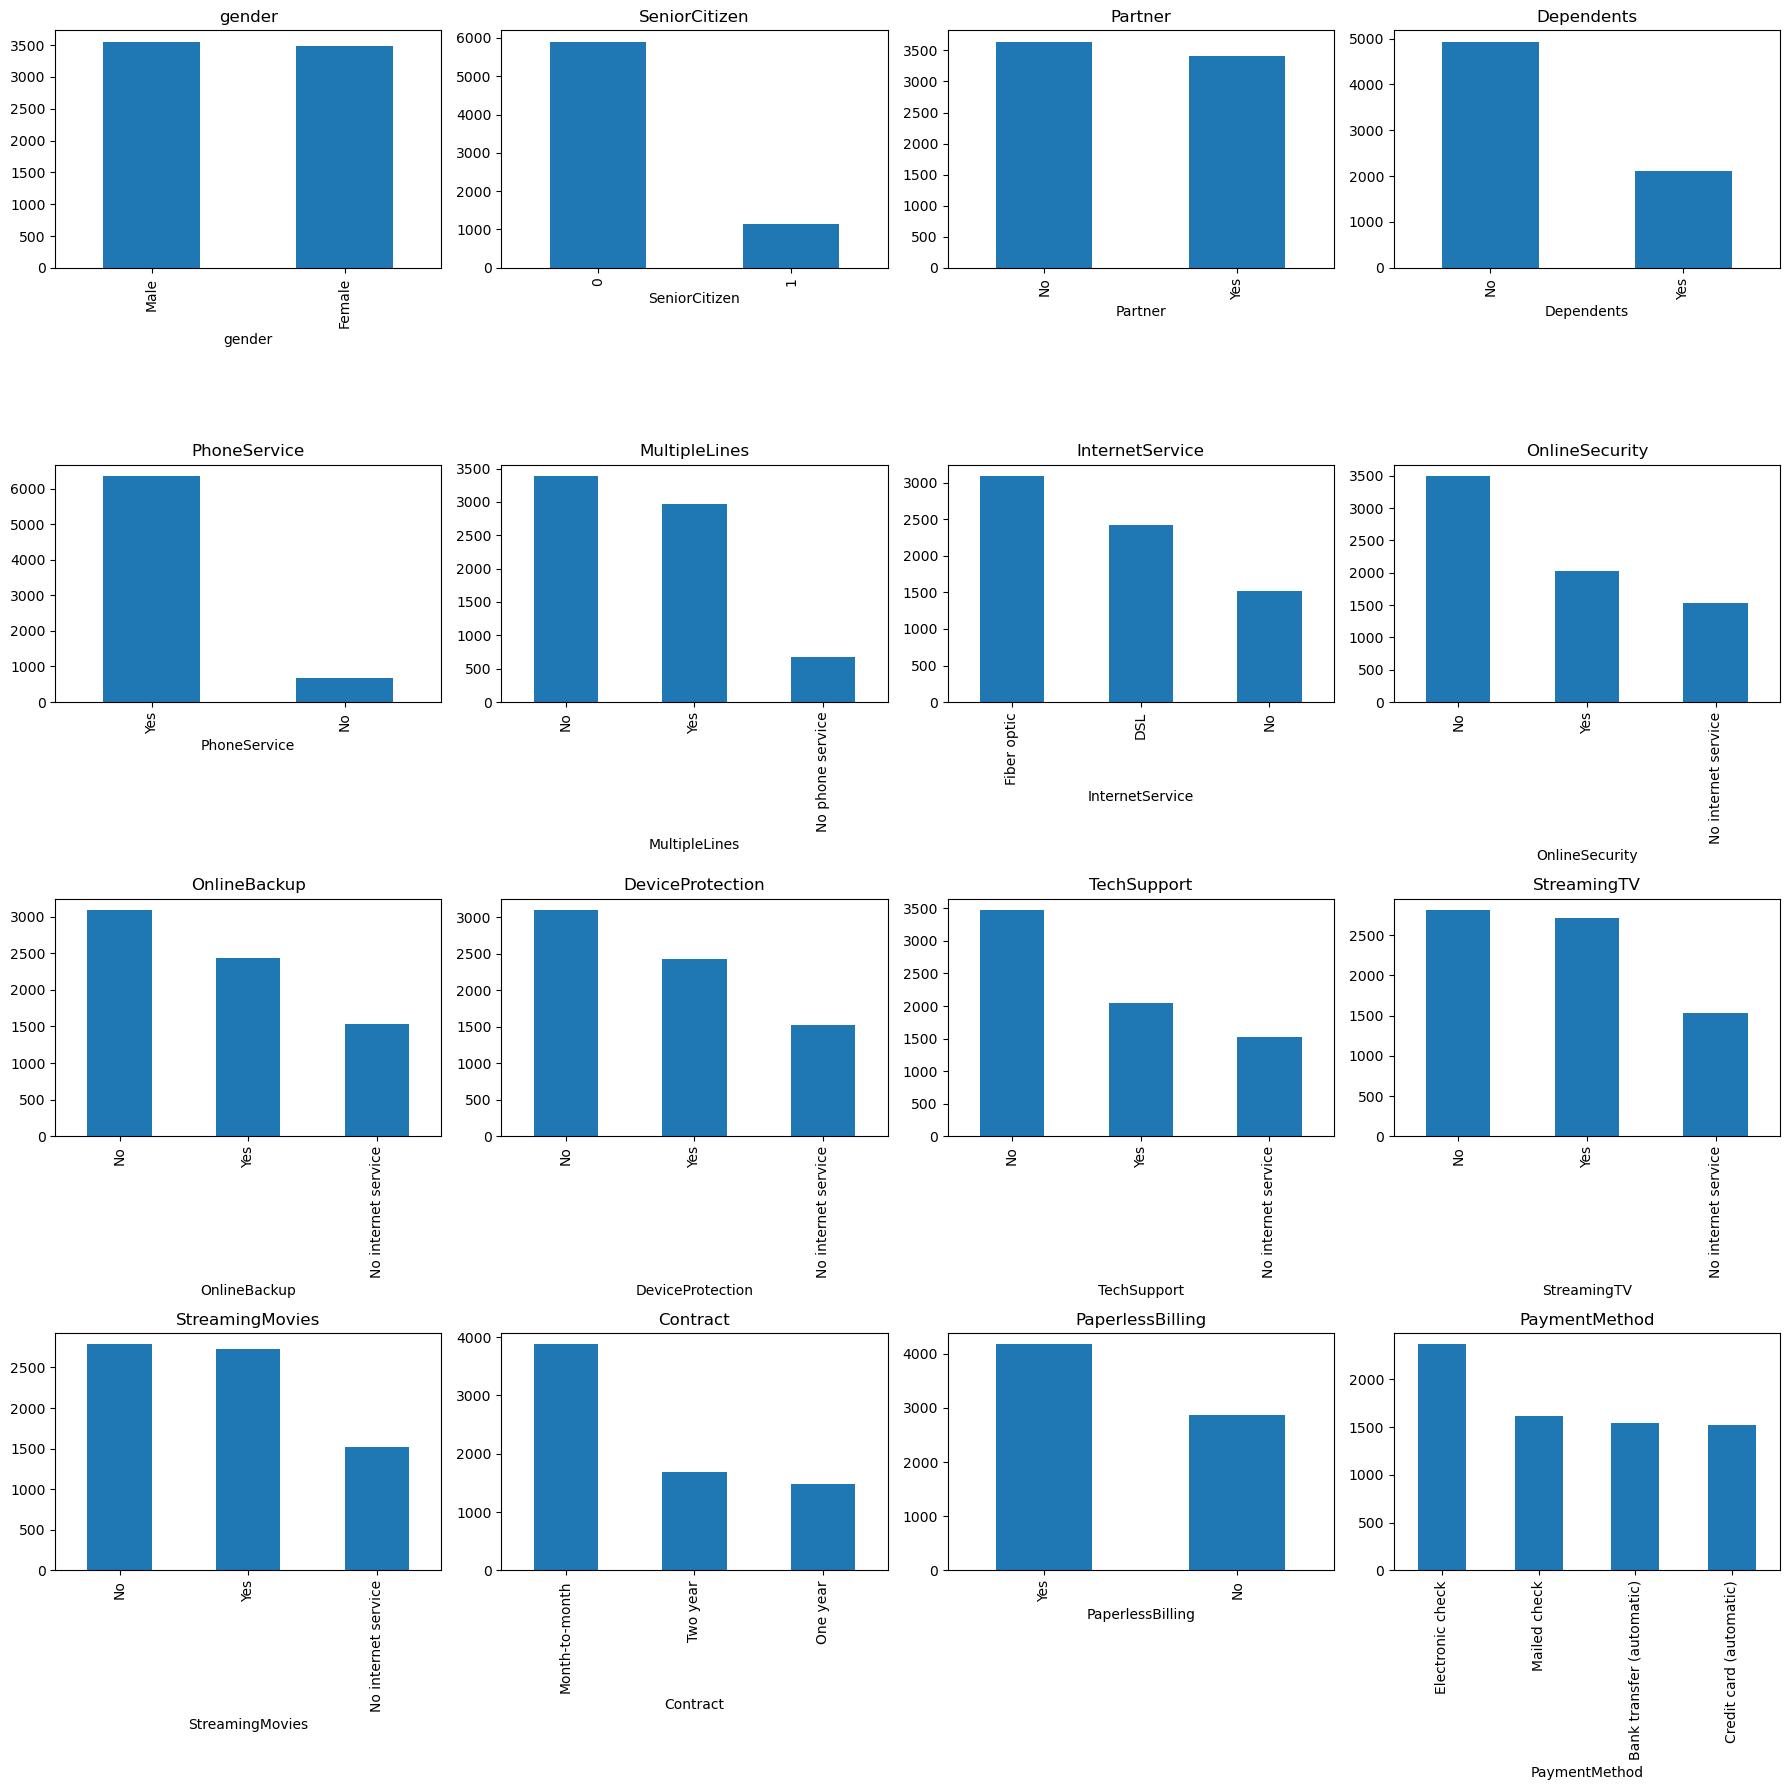

In [20]:
ROWS, COLS = 4, 4
fig, ax = plt.subplots(ROWS, COLS, figsize=(18,18))
row, col = 0, 0

for i, categorical_feature in enumerate(categorical_features):
    if col == COLS:
        row += 1
        col = 0
    df[categorical_feature].value_counts().plot(kind='bar', ax=ax[row, col])
    ax[row, col].set_title(categorical_feature)
    col += 1

plt.tight_layout()
plt.show()

The next step is to look at categorical features in relation to the target variable. We do this only for contract feature. Users who have a month-to-month contract are more likely to churn than users with long term contracts.

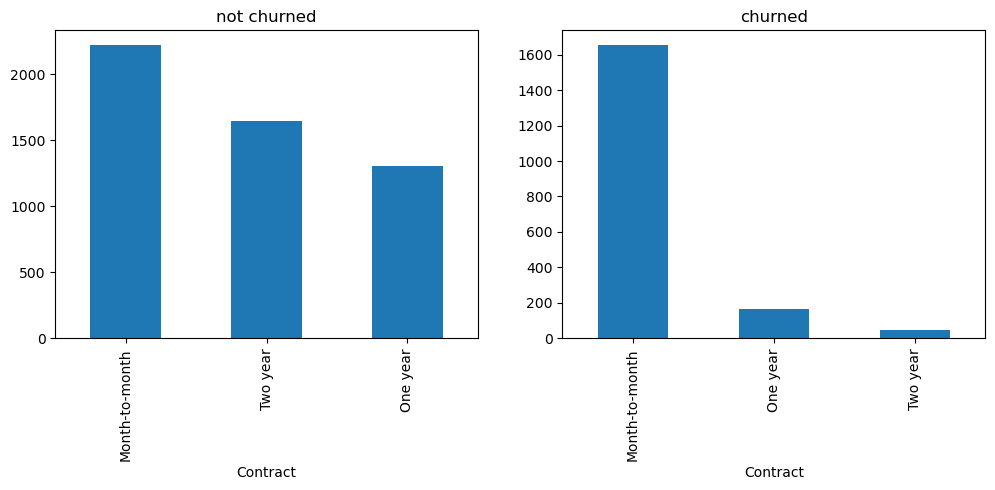

In [21]:
feature = 'Contract'
fig, ax = plt.subplots(1,2,figsize=(12,4))
df[df.Churn == "No"][feature].value_counts().plot(kind='bar', ax=ax[0]).set_title('not churned')
df[df.Churn == "Yes"][feature].value_counts().plot(kind='bar', ax=ax[1]).set_title('churned')
plt.show()

### Target Variable Distribution

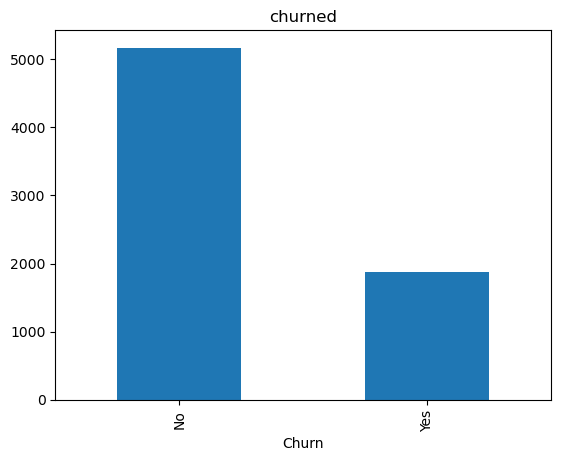

In [24]:
df[target].value_counts().plot(kind='bar').set_title('churned')
plt.show()

Target Variable distribution shows that we are dealing with an imbalanced problem as there are many more non-churned as compared to churned users. The model would achieve high accuracy as it would monthly predict majority class-users who didnt churn in our example.

Few Things we can do to minimize the influence of imbalanced dataset
1. resample data
2. collect more samples
3. use precision and recall as accuracy metrics

### Outliers Analysis with IQR Method

In [26]:
x = ['tenure','MonthlyCharges']
def count_outliers(data,col):
    q1 = data[col].quantile(0.25,interpolation='nearest')
    q2 = data[col].quantile(0.5,interpolation='nearest')
    q3 = data[col].quantile(0.75,interpolation='nearest')
    q4 = data[col].quantile(1,interpolation='nearest')
    IQR = q3-q1
    global LLP
    global ULP
    LLP = q1 - 1.5*IQR
    ULP = q3 + 1.5*IQR
    if data[col].min() > LLP and data[col].max() < ULP:
        print("No Outliers in",i)
    else:
        print("There are outliers in",i)
        x = data[data[col]<LLP][col].size
        y = data[data[col]>ULP][col].size
        a.append(i)
        print("Count of Outliers are:",x+y)
global a
a = []
for i in x:
    count_outliers(df,i)

No Outliers in tenure
No Outliers in MonthlyCharges


### Cleaning and Transforming Data

In [27]:
df.drop(['customerID'],axis = 1,inplace = True)

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dropped customerID because it is not needed

### One Hot Encoding

In [37]:
# Apply pd.get_dummies to perform one-hot encoding
df1 = pd.get_dummies(data=df, columns=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn'], drop_first=True)

# Convert boolean columns (True/False) to numeric (1/0) if any exist
df1 = df1.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Check the first few rows of the resulting dataframe to ensure correct encoding
print(df1.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                               1                  0  ...                0   
1                               0                  0  ...                0   
2                         

C:\Users\Admin\AppData\Local\Temp\ipykernel_8064\3021189777.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df1 = df1.applymap(lambda x: 1 if x is True else (0 if x is False else x))


In [38]:
df1.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [31]:
df1.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

### Rearranging Columns

In [35]:
df1 = df1[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes']]

In [39]:
df1.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [40]:
df1.shape

(7043, 31)

In [44]:
from sklearn.impute import SimpleImputer
import numpy as np

# The Imputer will replace missing values with the mean of the non-missing values for the respective column
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")

# Correcting the assignment by using square bracket notation
df1['TotalCharges'] = imputer.fit_transform(df1['TotalCharges'].values.reshape(-1, 1))

### Feature Scaling

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [47]:
scaler.fit(df1.drop(['Churn_Yes'],axis = 1))
scaled_features = scaler.transform(df1.drop('Churn_Yes',axis = 1))

### Feature Selection

In [50]:
from sklearn.model_selection import train_test_split
X = scaled_features
Y = df1['Churn_Yes']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=44)

### Prediction using Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

logmodel = LogisticRegression()
logmodel.fit(X_train,Y_train)

LogisticRegression()

In [56]:
predLR = logmodel.predict(X_test)
predLR

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [58]:
Y_test

5616    0
2937    0
1355    0
5441    1
3333    0
       ..
2797    1
412     0
174     0
5761    0
5895    0
Name: Churn_Yes, Length: 2113, dtype: int64

In [59]:
print(classification_report(Y_test, predLR))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1557
           1       0.65      0.53      0.58       556

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.73      2113
weighted avg       0.79      0.80      0.79      2113



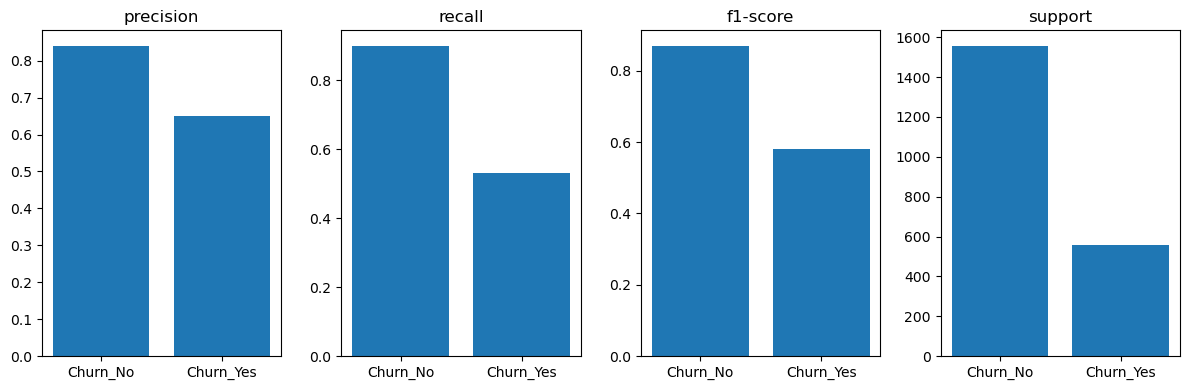

In [64]:
# Calculate the classification report
report = classification_report(Y_test, predLR, target_names=['Churn_No', 'Churn_Yes'])

# Split the report into lines
lines = report.split("\n")

# Split each line into parts
parts = [line.split() for line in lines[2:-5]]

# Extract the metrics for each class
class_metrics = dict()
for part in parts:
    class_metrics[part[0]] = {'precision': float(part[1]), 'recall': float(part[2]), 'f1-score': float(part[3]), 'support': int(part[4])}

# Create a bar chart for each metric
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
metrics = ['precision', 'recall', 'f1-score', 'support']

for i, metric in enumerate(metrics):
    ax[i].bar(class_metrics.keys(), [class_metrics[key][metric] for key in class_metrics.keys()])
    ax[i].set_title(metric)

# Display the plot
plt.tight_layout()
plt.show()


In [66]:
confusion_matrix_LR = confusion_matrix(Y_test, predLR)

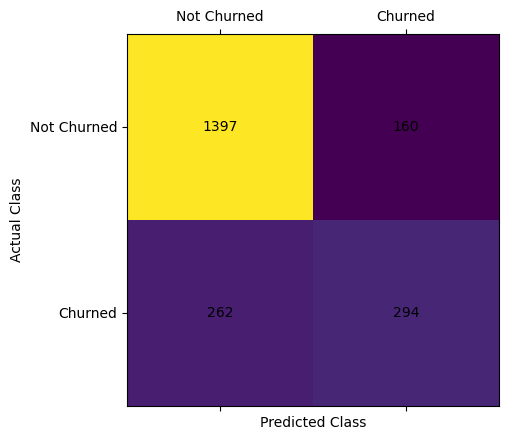

In [67]:
#Create a heatmap of the matrix using matshow()
plt.matshow(confusion_matrix(Y_test, predLR))

#add labels for the x and y axes
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(2):
    for j in range(2):
        plt.text(j,i,confusion_matrix_LR[i,j], ha='center',va='center')

#add custom labels for x and y ticks
plt.xticks([0,1],["Not Churned", "Churned"])
plt.yticks([0,1],["Not Churned", "Churned"])
plt.show()

In [68]:
logmodel.score(X_train, Y_train)

0.8064908722109534

In [69]:
accuracy_score(Y_test, predLR)

0.8002839564600095

### Prediction using Support Vector Classifier

In [72]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, Y_train)
y_pred_svc = svc.predict(X_test)

In [73]:
print(classification_report(Y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1557
           1       0.67      0.48      0.56       556

    accuracy                           0.80      2113
   macro avg       0.75      0.70      0.71      2113
weighted avg       0.79      0.80      0.79      2113



In [74]:
confusion_matrix_svc = confusion_matrix(Y_test,y_pred_svc)

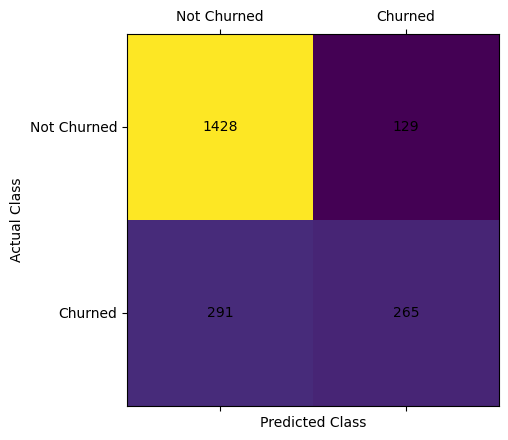

In [76]:
#Create a heatmap of the matrix using matshow()
plt.matshow(confusion_matrix_svc)

#add labels for the x and y axes
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(2):
    for j in range(2):
        plt.text(j,i,confusion_matrix_svc[i,j], ha='center',va='center')

#add custom labels for x and y ticks
plt.xticks([0,1],["Not Churned", "Churned"])
plt.yticks([0,1],["Not Churned", "Churned"])
plt.show()

In [78]:
svc.score(X_train,Y_train)

0.8170385395537525

In [79]:
accuracy_score(Y_test, y_pred_svc)

0.8012304779933743

### Prediction using Decision Tree Classifier

In [82]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(X_train, Y_train)
y_pred_dtc = dtc.predict(X_test)

In [83]:
print(classification_report(Y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1557
           1       0.48      0.47      0.48       556

    accuracy                           0.73      2113
   macro avg       0.65      0.64      0.65      2113
weighted avg       0.73      0.73      0.73      2113



In [84]:
confusion_matrix_dtc = confusion_matrix(Y_test, y_pred_dtc)

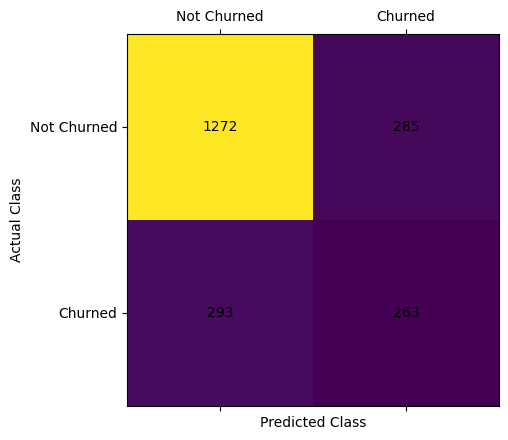

In [86]:
#Create a heatmap of the matrix using matshow()
plt.matshow(confusion_matrix_dtc)

#add labels for the x and y axes
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(2):
    for j in range(2):
        plt.text(j,i,confusion_matrix_dtc[i,j], ha='center',va='center')

#add custom labels for x and y ticks
plt.xticks([0,1],["Not Churned", "Churned"])
plt.yticks([0,1],["Not Churned", "Churned"])
plt.show()

In [87]:
dtc.score(X_train, Y_train)

0.9987829614604462

In [88]:
accuracy_score(Y_test, y_pred_dtc)

0.7264552768575485

### Prediction using KNN Classifier

In [89]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 30)
knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=30)

In [90]:
pred_knn=knn.predict(X_test)

In [91]:
error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train, Y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i !=Y_test))

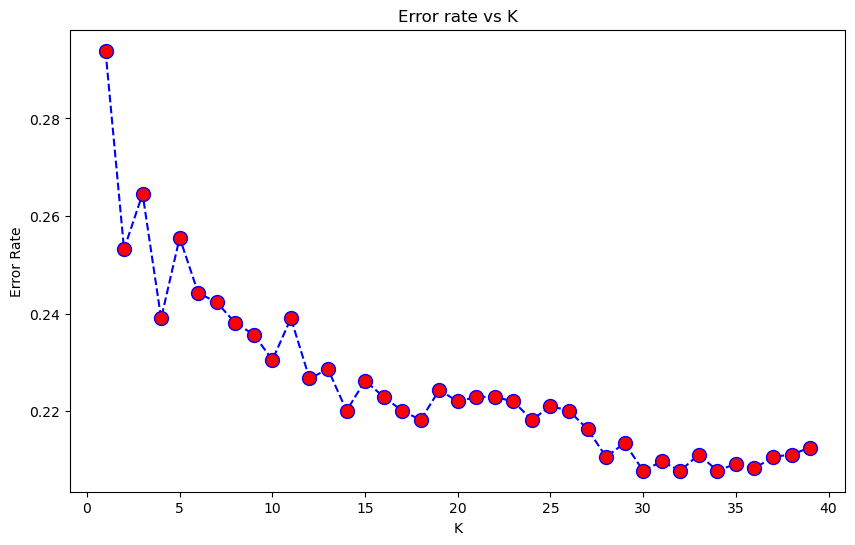

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='--', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [101]:
print(classification_report(Y_test,pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1557
           1       0.62      0.55      0.58       556

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.79      0.79      0.79      2113



In [102]:
confusion_matrix_knn=confusion_matrix(Y_test, pred_knn)

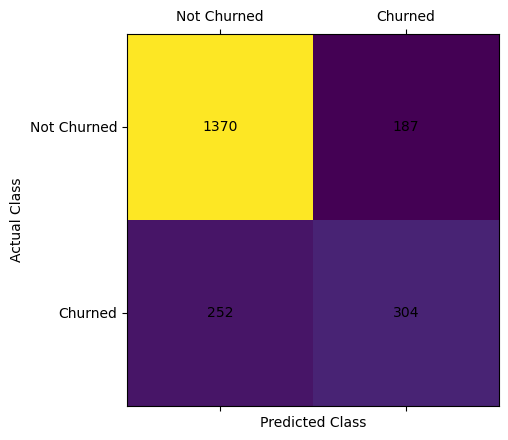

In [103]:
#Create a heatmap of the matrix using matshow()
plt.matshow(confusion_matrix_knn)

#add labels for the x and y axes
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(2):
    for j in range(2):
        plt.text(j,i,confusion_matrix_knn[i,j], ha='center',va='center')

#add custom labels for x and y ticks
plt.xticks([0,1],["Not Churned", "Churned"])
plt.yticks([0,1],["Not Churned", "Churned"])
plt.show()

In [104]:
knn.score(X_train, Y_train)

0.8008113590263691

In [106]:
accuracy_score(Y_test,pred_knn)

0.792238523426408

### Conclusion